# ModHav Synthetic Dataset v2

OPTION 3

In [9]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
from config.config import *
from config.experiments import ExperimentConfig

import src.data.saving as saving
import src.utils.visuals as visuals

from src.data.preprocessing import preprocess_synthetic
from src.data.synthetic import Havlicek_synthetic_dataset
from src.data.saving import candidate_exists, svm_exists, load_parameter_train, load_svm_results
from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.training_candidate import train_candidate_optuna_angles
from src.optimization.classical_base import classical_baseline
from src.utils.visuals import *

In [10]:
# ── 1. Data ────────────────────────────────────────────────────────────────
X, y = Havlicek_synthetic_dataset(seed=45)
X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

RESULTS_DIR = 'Results/Havlicek Synthetic v2'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

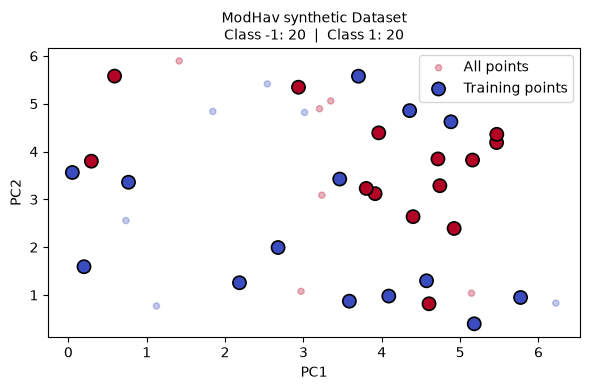

In [11]:
# ── 2. Dataset structure ─────────────────────────────────────────────────────────
graph_dataset('ModHav synthetic', X, y, X_train, y_train, 'yes')

In [12]:
# ── 3. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# variant          → 'geometric', 'haar', 'angles'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
    ExperimentConfig(
        name             = 'optuna_angles',
        optimizer        = 'optuna',
        variant          = 'angles',
        subset_method    = 'none',
        optimizer_kwargs = {'stage1_trials': 100, 'stage2_trials': 100},
    ),
    ExperimentConfig(
        name             = 'optuna angles',
        optimizer        = 'optuna',
        variant          = 'angles',
        subset_method    = 'none',
        optimizer_kwargs = {'stage1_trials': 100, 'stage2_trials': 100},
    ),
    ExperimentConfig(
        name             = 'optuna, geometric',
        optimizer        = 'optuna',
        variant          = 'geometric',
        subset_method    = 'none',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': 100},
    ),
]

In [13]:
# ── 4. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}

# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)
 
summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}

# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")

    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))
    
    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
    
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
    
    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }

[I 2026-08-20 17:56:43,307] A new study created in memory with name: no-name-2115cbd5-75a2-4fa2-848c-c4fa822fc831



Loaded results of SVM for 'Classical_baseline'

────────────────────────────────────────────────────────────
 optuna_angles  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna_angles'
Loading cached SVM results for 'optuna_angles'

────────────────────────────────────────────────────────────
 optuna angles  [optuna + none]
────────────────────────────────────────────────────────────


[I 2026-08-20 17:56:46,104] Trial 0 finished with value: 6.631345081015819 and parameters: {'gate_0': 'CNOT', 'gate_1': 'RY', 'gate_2': 'RX', 'gate_3': 'RY', 'gate_4': 'RY', 'gate_5': 'RY', 'gate_6': 'CNOT', 'gate_7': 'RY', 'gate_8': 'RX', 'gate_9': 'H', 'gate_10': 'H', 'gate_11': 'RX', 'gate_12': 'RX', 'gate_13': 'I', 'gate_14': 'RZ', 'gate_15': 'RZ'}. Best is trial 0 with value: 6.631345081015819.
[I 2026-08-20 17:56:48,234] Trial 1 finished with value: 6.690019162697652 and parameters: {'gate_0': 'CNOT', 'gate_1': 'H', 'gate_2': 'RY', 'gate_3': 'I', 'gate_4': 'I', 'gate_5': 'RZ', 'gate_6': 'I', 'gate_7': 'CNOT', 'gate_8': 'CNOT', 'gate_9': 'I', 'gate_10': 'CNOT', 'gate_11': 'RZ', 'gate_12': 'RY', 'gate_13': 'RZ', 'gate_14': 'I', 'gate_15': 'H'}. Best is trial 1 with value: 6.690019162697652.
[I 2026-08-20 17:56:52,893] Trial 2 finished with value: 6.538100735376173 and parameters: {'gate_0': 'RY', 'gate_1': 'I', 'gate_2': 'I', 'gate_3': 'H', 'gate_4': 'I', 'gate_5': 'RX', 'gate_6': 

Saved candidate  → Results/Havlicek Synthetic v2/optuna angles_stage1/candidate.pkl


[I 2026-08-20 18:01:15,161] Trial 0 finished with value: 0.09427643627172559 and parameters: {'angle_0': 5.256432650474166, 'angle_1': 5.446908900008374, 'angle_2': 0.0591636571493717, 'angle_3': 2.935150231615184, 'angle_4': 6.086730942917025, 'angle_5': 0.6347089469614516, 'angle_6': 5.801829108308564, 'angle_7': 4.623738632388177, 'angle_8': 2.8445045017137938, 'angle_9': 6.084845611252058, 'angle_10': 2.464790667218632, 'angle_11': 0.6473186757415902, 'angle_12': 4.977468218372348, 'angle_13': 2.325224688257425, 'angle_14': 1.0261835801562762, 'angle_15': 2.2338073656726114}. Best is trial 0 with value: 0.09427643627172559.
[I 2026-08-20 18:01:17,807] Trial 1 finished with value: 0.010428184051933053 and parameters: {'angle_0': 5.762008395485843, 'angle_1': 3.259988586631588, 'angle_2': 1.736258856458826, 'angle_3': 0.9556127584183616, 'angle_4': 4.071250325460222, 'angle_5': 3.817958986259555, 'angle_6': 0.6766418657524168, 'angle_7': 3.0577162822222776, 'angle_8': 2.1707874370754

Saved candidate  → Results/Havlicek Synthetic v2/optuna angles/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/Havlicek Synthetic v2/optuna angles/svm.pkl

REPORT: optuna angles | 100 trials
Best C            : 100
Best CV accuracy  : 0.7833
Test accuracy     : 0.5833
              precision    recall  f1-score   support

          -1       0.56      0.83      0.67         6
           1       0.67      0.33      0.44         6

    accuracy                           0.58        12
   macro avg       0.61      0.58      0.56        12
weighted avg       0.61      0.58      0.56        12


────────────────────────────────────────────────────────────
 optuna, geometric  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna, geometric'
Loading cached SVM results for 'optuna, geometric'


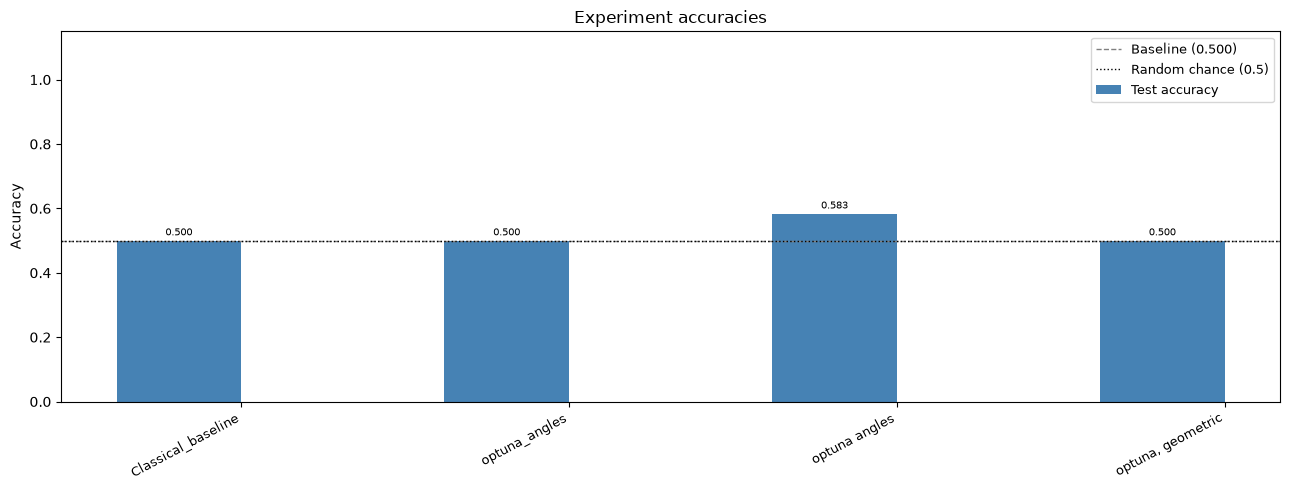

Saved → Results/Havlicek Synthetic v2/accuracy_comparison.png


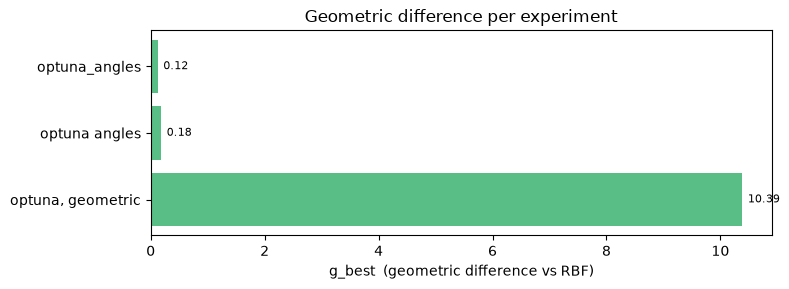

Saved → Results/Havlicek Synthetic v2/g_best_comparison.png


In [14]:
# ── 6. Visualizations ──────────────────────────────────────────────────────────

plot_accuracy(summary, ['test'])
plot_g_best(summary)

In [15]:
data = load_parameter_train(config.name)   # or config.load_from or config.name
candidate = data['candidate']

gates  = [gene.gate  for gene in candidate.genes]
angles = [gene.angle for gene in candidate.genes]

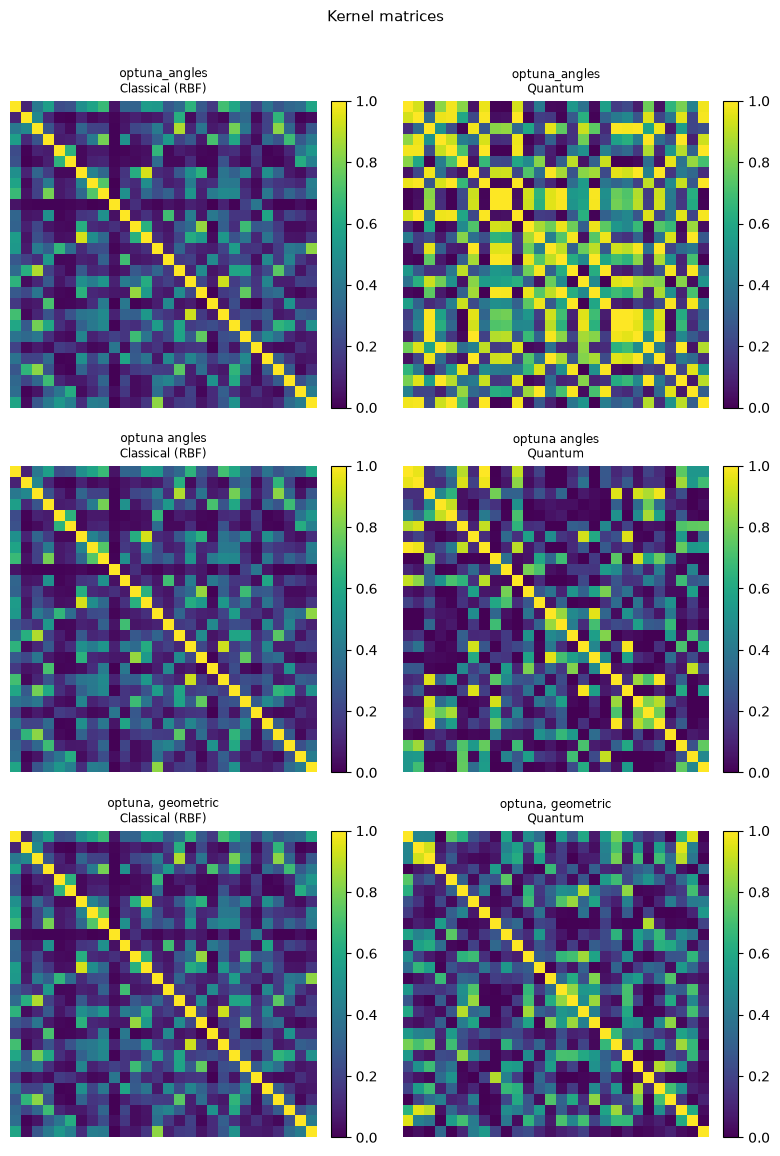

Saved → Results/Havlicek Synthetic v2/kernel_heatmaps.png


In [16]:
plot_kernel_heatmaps(summary)